# Implicit FWI with a pseudo-Hessian preconditioner (Overthrust)

Reproduces the Overthrust example of *Accelerating High Resolution Implicit Full Waveform
Inversion* (Shaowen Wang and Tariq Alkhalifah, *Geophysics*), first presented as the EAGE
abstract *Implicit full waveform inversion with energy-weighted gradient*
([10.3997/2214-4609.202510069](https://doi.org/10.3997/2214-4609.202510069)).
The stand-alone reproduction package is
[DeepWave-KAUST/ifwi-pub](https://github.com/DeepWave-KAUST/ifwi-pub). Here the velocity
network is sweep-nn's `VelocityINR` and the wave equation is sweep's compiled acoustic
solver.

Three inversions from the same smoothed starting model:

1. **Conventional FWI**: Adam on the grid velocity.
2. **Implicit FWI**: `vp = vp_init + vp_std · SIREN(z, x)`, Adam on the network weights.
3. **Implicit FWI + pseudo-Hessian**: the velocity gradient is divided by
   `sqrt(source illumination · receiver illumination)` before it reaches the weights,
   which lifts the poorly illuminated deep part of the model.

**Needs** a CUDA GPU (the illumination comes from the compiled `impl='c'` solver) and
`pip install sweep-nn sweep-solver`. Run it from this directory: it imports
`ifwi_models.py`, which holds the two velocity models. The full 500 iterations take
about 7 minutes on an RTX 6000 Ada; `IFWI_EPOCHS=60` gives a quick check.

## Setup: models, acquisition, solver and observed data

In [1]:
import os

# ---------------- Overthrust / pseudo-Hessian configuration ----------------
DH, DT = 25.0, 0.002
SPATIAL_ORDER, ABCN = 8, 20               # 8th-order space, 2nd-order time
NT, FM, DELAY = 1500, 8.0, 0.3            # 3.0 s record, 8 Hz Ricker
SRC_INTERVAL, REC_INTERVAL = 4, 1         # a source every 100 m, a receiver at every surface point
BATCH = 8                                 # shots per iteration, drawn at random
SEED = 19491001

CONV_LR = 20.0                            # conventional FWI: Adam on the grid (m/s)
NN_LR, LR_DECAY = 1e-4, 0.9995            # implicit FWI: Adam on the weights, exponential decay
VP_STD = 400.0                            # vp = vp_init + VP_STD * net(z, x)
HIDDEN, LAYERS, OMEGA = 128, 6, 30.0      # SIREN width, hidden layers, sine frequency
EXP3_LABEL = "iFWI + pseudo-Hessian"

EPOCHS = int(os.environ.get("IFWI_EPOCHS", "500"))
CONV_EPOCHS = min(300, EPOCHS)            # conventional FWI diverges past ~300 iterations here

In [2]:
import time
import numpy as np, torch, matplotlib.pyplot as plt
from sweep.equations import Acoustic
from sweep.propagator.torch import PropTorch
from sweep_nn import VelocityINR
import ifwi_models          # the velocity models, embedded: nothing to download

dev = "cuda"
torch.manual_seed(SEED); np.random.seed(SEED)
print("GPU:", torch.cuda.get_device_name(0))

vp_true, vp_smooth = ifwi_models.overthrust("true"), ifwi_models.overthrust("smooth")
shape = vp_true.shape; nz, nx = shape
vp_true_t, vp_smooth_t = (torch.tensor(m, device=dev) for m in (vp_true, vp_smooth))
print(f"Overthrust: shape={shape}, dh={DH} m, vp in [{vp_true.min():.0f}, {vp_true.max():.0f}] m/s")

t = np.arange(NT, dtype=np.float32) * DT - DELAY                    # Ricker wavelet
a = (np.pi * FM * t) ** 2
wavelet = ((1.0 - 2.0 * a) * np.exp(-a)).astype(np.float32)
sx = np.arange(0, nx, SRC_INTERVAL)                                 # surface survey, grid points [x, z]
sources = np.stack([sx, np.zeros_like(sx)], 1).astype(np.int64)
rx = np.arange(0, nx, REC_INTERVAL)
receivers = np.repeat(np.stack([rx, np.zeros_like(rx)], 1)[None], len(sources), 0).astype(np.int64)
print(f"{len(sources)} shots, {receivers.shape[1]} receivers, nt={NT}, epochs={EPOCHS}")

solver = PropTorch(Acoustic(spatial_order=SPATIAL_ORDER, device=dev), shape=shape, dh=DH, dt=DT,
                   abcn=ABCN, free_surface=False, source_type=["h1"], receiver_type=["h1"],
                   impl="c")
print("solver impl =", solver.impl, "| gradient memory:", solver.memory_strategy)

t0 = time.time()
with torch.no_grad():                                               # observed data from the true model
    observed = torch.cat([solver(wavelet, sources[i:i + 16], receivers[i:i + 16], models=[vp_true_t])
                          for i in range(0, len(sources), 16)])
print(f"observed data {tuple(observed.shape)} generated in {time.time() - t0:.1f} s")

GPU: NVIDIA RTX 6000 Ada Generation
Overthrust: shape=(187, 401), dh=25.0 m, vp in [2529, 6000] m/s
101 shots, 401 receivers, nt=1500, epochs=500


solver impl = c | gradient memory: boundary


observed data (101, 1500, 401, 1) generated in 0.3 s


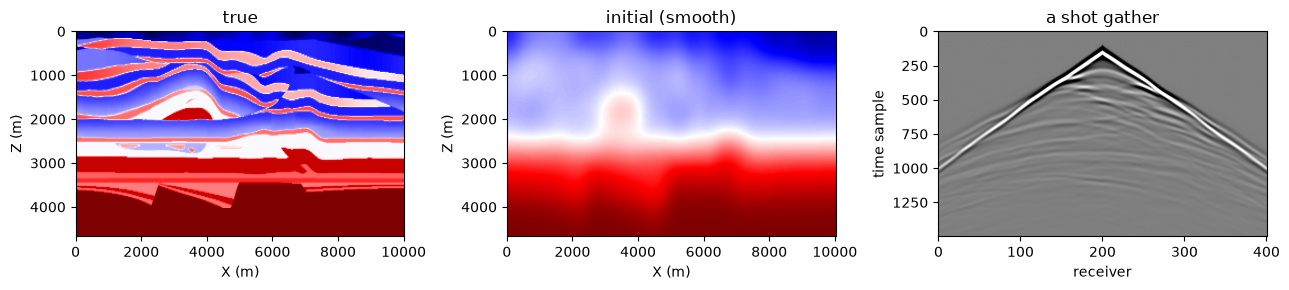

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
ext = [0, nx*DH, nz*DH, 0]
vk = dict(cmap="seismic", aspect="auto", extent=ext, vmin=vp_true.min(), vmax=vp_true.max())
for a, m, t in zip(ax[:2], [vp_true, vp_smooth], ["true", "initial (smooth)"]):
    im = a.imshow(m, **vk); a.set_title(t); a.set_xlabel("X (m)"); a.set_ylabel("Z (m)")
g = observed[len(sources)//2, :, :, 0].detach().cpu().numpy()
v = np.percentile(np.abs(g), 98)
ax[2].imshow(g, cmap="gray", aspect="auto", vmin=-v, vmax=v)
ax[2].set_title("a shot gather"); ax[2].set_xlabel("receiver"); ax[2].set_ylabel("time sample")
plt.tight_layout(); plt.show()

## Gradient before and after preconditioning (manuscript Figure 3)

The gradient of the first iteration: the same mini-batch `run_inversion` draws first,
at the initial model. Dividing by the illumination lifts the deep part, which the
surface sources and receivers barely see. Colour limits are the signed 2nd and 98th
percentiles below the top 500 m, so the acquisition footprint does not set them.

first mini-batch: [10 13 25 27 37 45 70 93]


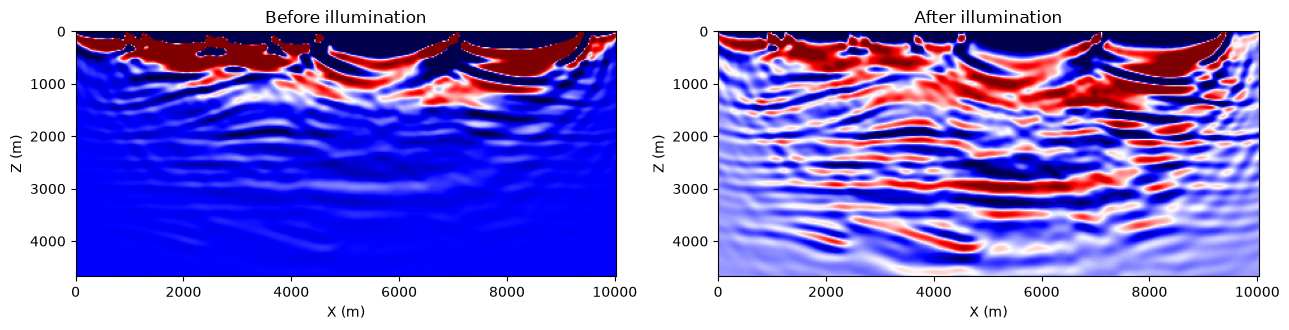

In [4]:
SKIP = 20                                  # 500 m: colour limits taken below the acquisition footprint

idx = np.random.default_rng(SEED).choice(len(sources), size=min(BATCH, len(sources)), replace=False)
print("first mini-batch:", np.sort(idx))

solver.compute_illumination = True
g_acc, s_acc = torch.zeros_like(vp_smooth_t), torch.zeros_like(vp_smooth_t)
for i in idx:
    vp_i = vp_smooth_t.clone().requires_grad_(True)
    syn_i = solver(wavelet, sources[i:i + 1], receivers[i:i + 1], models=[vp_i])
    (g_i,) = torch.autograd.grad((syn_i - observed[i:i + 1]).pow(2).mean(), vp_i)
    g_acc += g_i
    s_acc += torch.sqrt(solver.source_illumination * solver.receiver_illumination)
solver.compute_illumination = False

g_before = g_acc.cpu().numpy()
g_after = (g_acc / (s_acc + 1e-11)).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
for a, (name, g) in zip(ax, [("Before illumination", g_before),
                             ("After illumination", g_after)]):
    lo, hi = np.percentile(g[SKIP:], [2, 98])                # signed, not abs
    a.imshow(g, cmap="seismic", aspect="auto", extent=[0, nx * DH, nz * DH, 0],
             vmin=lo, vmax=hi)
    a.set_title(name); a.set_xlabel("X (m)"); a.set_ylabel("Z (m)")
plt.tight_layout(); plt.show()

## The inversion loop

One loop drives all three experiments: `model_fn()` returns the velocity grid and Adam
steps on `params`, the grid itself for conventional FWI, the network weights for
implicit FWI. Every experiment draws the same random mini-batches (`SEED`), so they
differ only in what is optimized.

With `use_ph=True` the gradient of the velocity grid is divided by the summed
illumination `Σ sqrt(s·r)` before it is back-propagated into the weights. The
source and receiver illumination `s`, `r` come straight off the solver
(`solver.source_illumination` / `solver.receiver_illumination`) after each shot's
backward pass. It is an extra grid pass, so it is on only while `use_ph` is.

In [5]:
def run_inversion(model_fn, params, *, epochs, lr, lr_decay=1.0, use_ph=False, eps_ill=1e-11,
                  log_every=50):
    solver.compute_illumination = use_ph
    rng = np.random.default_rng(SEED)
    opt = torch.optim.Adam(params, lr=lr, eps=1e-22)
    sched = torch.optim.lr_scheduler.ExponentialLR(opt, lr_decay) if lr_decay < 1.0 else None
    hist = {"loss": [], "rmse": []}
    for ep in range(epochs):
        idx = rng.choice(len(sources), size=min(BATCH, len(sources)), replace=False)
        opt.zero_grad(set_to_none=True)
        vp = model_fn()
        if use_ph:          # shot by shot, so that each shot brings its own illumination
            g_vp, scale, loss = torch.zeros_like(vp), torch.zeros_like(vp), 0.0
            for s in idx:
                syn = solver(wavelet, sources[s:s + 1], receivers[s:s + 1], models=[vp])
                loss_s = (syn - observed[s:s + 1]).pow(2).mean()
                g_vp += torch.autograd.grad(loss_s, vp, retain_graph=True)[0]
                scale += torch.sqrt(solver.source_illumination * solver.receiver_illumination)
                loss += float(loss_s.detach()) / len(idx)
            grads = torch.autograd.grad(vp, params, grad_outputs=g_vp / (scale + eps_ill))
            for p, g in zip(params, grads):
                p.grad = g
        else:
            syn = solver(wavelet, sources[idx], receivers[idx], models=[vp])
            loss_t = (syn - observed[idx]).pow(2).mean()
            loss_t.backward()
            loss = float(loss_t.detach())
        opt.step()
        if sched is not None:
            sched.step()
        with torch.no_grad():
            rmse = float(torch.sqrt(torch.mean((model_fn() - vp_true_t) ** 2)))
        hist["loss"].append(loss); hist["rmse"].append(rmse)
        if ep % log_every == 0 or ep == epochs - 1:
            print(f"  iter {ep:4d}  loss {loss:.4e}  model RMSE {rmse:6.1f} m/s", flush=True)
    with torch.no_grad():
        hist["vp"] = model_fn().cpu().numpy()
    return hist

In [6]:
print("Experiment 1/3 - conventional FWI (optimize the grid velocity directly)")
t0 = time.time()
vp_grid = vp_smooth_t.clone().requires_grad_(True)
h_conv = run_inversion(lambda: vp_grid, [vp_grid], epochs=CONV_EPOCHS, lr=CONV_LR)
print(f"  {time.time() - t0:.0f} s")

Experiment 1/3 - conventional FWI (optimize the grid velocity directly)
  iter    0  loss 1.6216e-02  model RMSE  427.4 m/s


  iter   50  loss 1.1253e-02  model RMSE  425.4 m/s


  iter  100  loss 7.4422e-03  model RMSE  435.0 m/s


  iter  150  loss 8.1196e-03  model RMSE  473.1 m/s


  iter  200  loss 5.9126e-03  model RMSE  497.4 m/s


  iter  250  loss 3.7736e-03  model RMSE  506.1 m/s


  iter  299  loss 6.0672e-03  model RMSE  513.0 m/s


  26 s


In [7]:
def siren_net():
    torch.manual_seed(SEED)                # the same initial weights for both implicit runs
    return VelocityINR(vp_smooth_t, vp_std=VP_STD, hidden_features=HIDDEN, hidden_layers=LAYERS,
                       first_omega0=OMEGA, hidden_omega0=OMEGA, use_hash_encoding=False).to(dev)

print("Experiment 2/3 - implicit FWI (SIREN)")
t0 = time.time()
net = siren_net()
print(f"  {sum(p.numel() for p in net.parameters()):,} network weights for {nz * nx:,} grid cells")
h_ifwi = run_inversion(net, list(net.parameters()), epochs=EPOCHS, lr=NN_LR, lr_decay=LR_DECAY)
print(f"  {time.time() - t0:.0f} s")

Experiment 2/3 - implicit FWI (SIREN)
  98,688 network weights for 74,987 grid cells


  iter    0  loss 1.6199e-02  model RMSE  428.0 m/s


  iter   50  loss 7.4304e-03  model RMSE  548.6 m/s


  iter  100  loss 2.8322e-03  model RMSE  592.9 m/s


  iter  150  loss 2.6941e-03  model RMSE  667.1 m/s


...

  iter  350  loss 6.1280e-04  model RMSE  708.4 m/s


  iter  400  loss 5.8030e-04  model RMSE  723.9 m/s


  iter  450  loss 3.0022e-04  model RMSE  729.5 m/s


  iter  499  loss 2.8034e-04  model RMSE  717.9 m/s


  47 s


In [8]:
print("Experiment 3/3 - implicit FWI + pseudo-Hessian")
t0 = time.time()
net = siren_net()
h3 = run_inversion(net, list(net.parameters()), epochs=EPOCHS, lr=NN_LR, lr_decay=LR_DECAY,
                   use_ph=True)
print(f"  {time.time() - t0:.0f} s")

Experiment 3/3 - implicit FWI + pseudo-Hessian


  iter    0  loss 1.6199e-02  model RMSE  428.1 m/s


  iter   50  loss 8.3188e-03  model RMSE  521.2 m/s


  iter  100  loss 2.6605e-03  model RMSE  540.2 m/s


  iter  150  loss 3.7514e-03  model RMSE  531.3 m/s


...

  iter  350  loss 4.9664e-04  model RMSE  367.8 m/s


  iter  400  loss 3.4476e-04  model RMSE  269.8 m/s


  iter  450  loss 1.7653e-04  model RMSE  221.4 m/s


  iter  499  loss 8.1524e-05  model RMSE  199.7 m/s


  310 s


## Comparison of the three inversions (manuscript Figure 4)

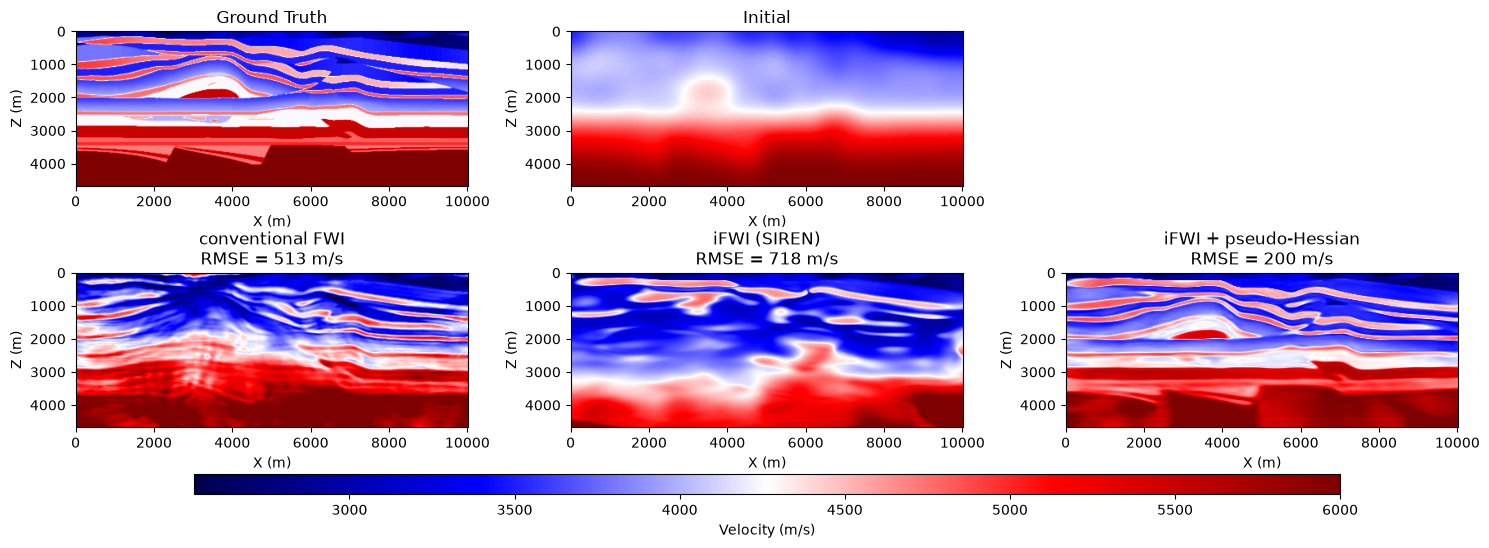

final model RMSE (m/s): {'conventional FWI': 513, 'iFWI (SIREN)': 718, 'iFWI + pseudo-Hessian': 200}


In [9]:
runs = [("conventional FWI", h_conv), ("iFWI (SIREN)", h_ifwi), (EXP3_LABEL, h3)]
rmse = lambda a: float(np.sqrt(np.mean((a - vp_true) ** 2)))
ext = [0, nx*DH, nz*DH, 0]
vk = dict(cmap="seismic", aspect="auto", extent=ext, vmin=vp_true.min(), vmax=vp_true.max())

fig, axes = plt.subplots(2, 3, figsize=(15, 6.0))
for a, (name, m) in zip(axes[0], [("Ground Truth", vp_true), ("Initial", vp_smooth)]):
    im = a.imshow(m, **vk); a.set_title(name)
    a.set_xlabel("X (m)"); a.set_ylabel("Z (m)")
axes[0, 2].axis("off")
for a, (name, h) in zip(axes[1], runs):                                          # the three inversions
    r = rmse(h["vp"])
    im = a.imshow(np.nan_to_num(h["vp"], nan=float(vp_true.mean())), **vk)
    a.set_title(f"{name}\nRMSE = {r:.0f} m/s" if np.isfinite(r) else f"{name}\n(diverged)")
    a.set_xlabel("X (m)"); a.set_ylabel("Z (m)")
plt.tight_layout(rect=[0, 0.07, 1, 1])
cb = fig.colorbar(im, ax=axes, orientation="horizontal", fraction=0.045, pad=0.10, aspect=55)
cb.set_label("Velocity (m/s)")
plt.show()

print("final model RMSE (m/s):", {name: (round(rmse(h["vp"])) if np.isfinite(rmse(h["vp"])) else "NaN") for name, h in runs})

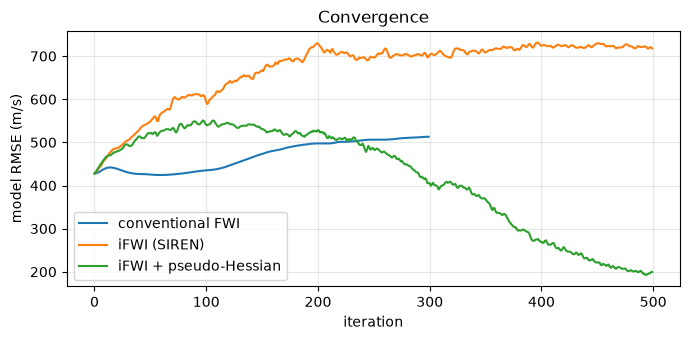

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.5))
for name, h in runs:
    ax.plot(h["rmse"], label=name)
ax.set_xlabel("iteration"); ax.set_ylabel("model RMSE (m/s)"); ax.set_title("Convergence")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## Result

Final model RMSE on an RTX 6000 Ada with sweep-solver 0.3.5: **513 / 718 / 200 m/s** for
conventional FWI / implicit FWI / implicit FWI + pseudo-Hessian. The paper reports
513 / 615 / 189.

Conventional FWI matches the paper exactly, since it involves no network. The two
implicit runs start from different random weights than the paper's code (`VelocityINR`
initializes its layers in a different order), so their numbers move; the conclusion
does not. The SIREN alone ends further from the true model than it started. With the
illumination preconditioner the same network recovers the layering, the anticline and
the faulted basement.